In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load and quick-prep (assuming the steps we've refined)
df = pd.read_csv(r'C:\Users\Asus\Downloads\Dataset_Predict The Fare Amount Of Future Rides Using Regression Analysis\uber.csv')
df.dropna(inplace=True)

# Fast-track Feature Engineering
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour'] = df['pickup_datetime'].dt.hour
df['year'] = df['pickup_datetime'].dt.year
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek

# Distance Calculation
def get_dist(lat1, lon1, lat2, lon2):
    p = np.pi/180
    a = 0.5 - np.cos((lat2-lat1)*p)/2 + np.cos(lat1*p) * np.cos(lat2*p) * (1-np.cos((lon2-lon1)*p))/2
    return 12742 * np.arcsin(np.sqrt(a)) # 2*R*asin...

df['dist_km'] = get_dist(df['pickup_latitude'], df['pickup_longitude'], 
                         df['dropoff_latitude'], df['dropoff_longitude'])

# Final Filter
df = df[(df['fare_amount'] > 0) & (df['dist_km'] > 0) & (df['dist_km'] < 100)]

In [2]:
X = df[['passenger_count', 'hour', 'year', 'day_of_week', 'dist_km']]
y = df['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
}

# Run Cross-Validation
for name, model in models.items():
    # cv=5 means 5-fold cross-validation
    # We use negative mean squared error because cross_val_score tries to 'maximize' a score
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    
    print(f"{name} Cross-Validation R2 Scores: {cv_scores}")
    print(f"{name} Average R2: {np.mean(cv_scores):.4f}\n")

Linear Regression Cross-Validation R2 Scores: [0.748284   0.743328   0.6937541  0.72909453 0.67628712]
Linear Regression Average R2: 0.7181

Random Forest Cross-Validation R2 Scores: [0.79977538 0.81122813 0.81001532 0.77433298 0.75500909]
Random Forest Average R2: 0.7901



In [4]:
# 1. Train the final Random Forest Model
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_final.fit(X_train, y_train)

# 2. Get predictions
y_pred = rf_final.predict(X_test)

# 3. Calculate Residuals (Actual - Predicted)
residuals = y_test - y_pred

# Create a temporary dataframe for analysis
results_df = X_test.copy()
results_df['Actual_Fare'] = y_test
results_df['Predicted_Fare'] = y_pred
results_df['Residual'] = residuals

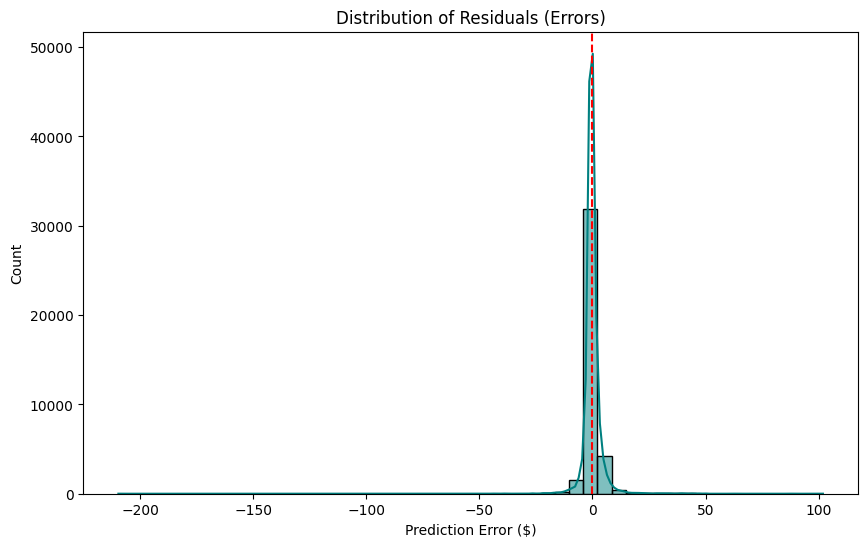

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color='teal')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals (Errors)')
plt.xlabel('Prediction Error ($)')
plt.show()

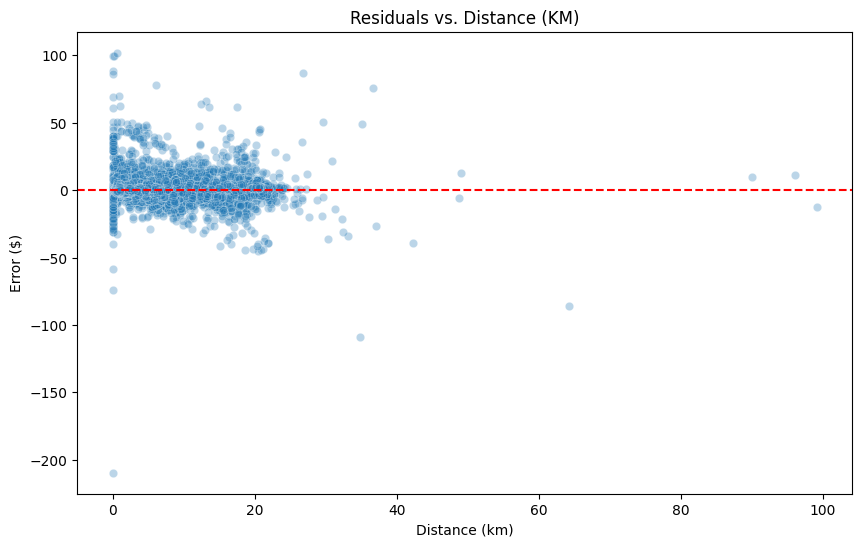

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=results_df['dist_km'], y=results_df['Residual'], alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Distance (KM)')
plt.xlabel('Distance (km)')
plt.ylabel('Error ($)')
plt.show()

In [7]:
import joblib

# Save the trained model to a file
joblib.dump(rf_final, 'uber_fare_model.pkl')

# Save the column names to ensure the order stays the same later
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("Model and columns saved successfully!")

Model and columns saved successfully!


In [8]:
def predict_uber_fare(plat, plon, dlat, dlon, pass_count, hour, year, day_of_week):
    # 1. Load the model
    model = joblib.load('uber_fare_model.pkl')
    
    # 2. Calculate distance using our Haversine function
    dist = get_dist(plat, plon, dlat, dlon)
    
    # 3. Create a DataFrame for the model
    # Note: Order must match X_train exactly
    input_data = pd.DataFrame([[pass_count, hour, year, day_of_week, dist]], 
                              columns=['passenger_count', 'hour', 'year', 'day_of_week', 'dist_km'])
    
    # 4. Predict
    prediction = model.predict(input_data)
    
    return round(prediction[0], 2)

# Test the function with a sample New York ride
# From Empire State Building to Times Square
test_fare = predict_uber_fare(40.7484, -73.9857, 40.7580, -73.9855, 1, 14, 2024, 2)
print(f"Estimated Uber Fare: ${test_fare}")

Estimated Uber Fare: $6.79


In [9]:
# Assuming 'new_rides_df' is a new dataset you just loaded
# new_rides_df['predicted_fare'] = rf_final.predict(new_rides_df[model_columns])

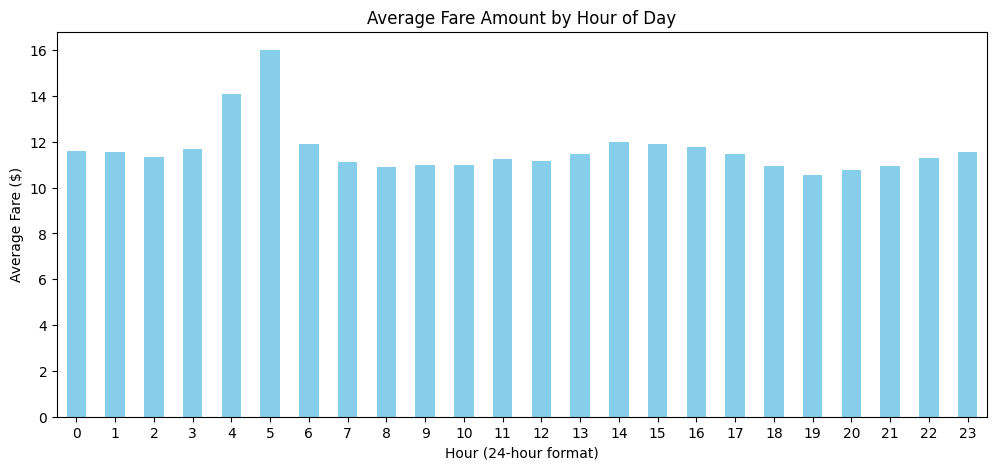

C:\Users\Asus\AppData\Local\Temp\ipykernel_6792\3550966545.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='fare_amount', data=df, palette='muted')


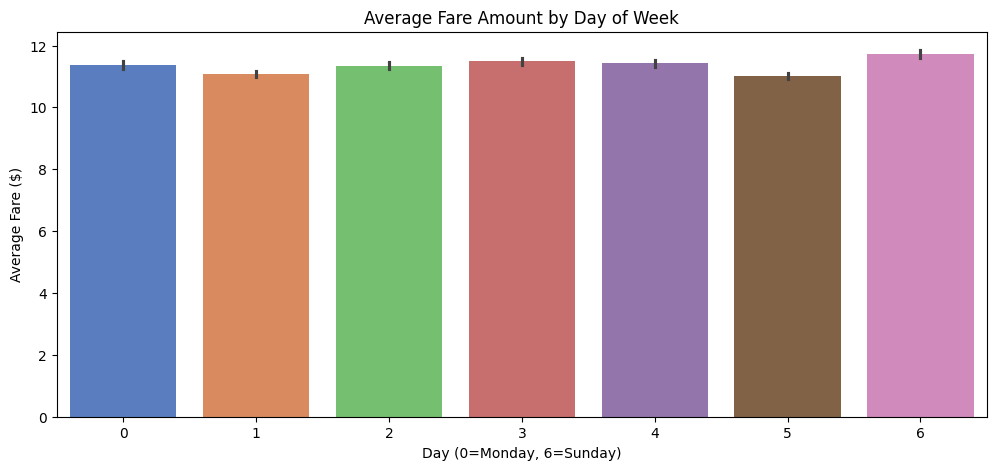

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average fare per hour
plt.figure(figsize=(12, 5))
df.groupby('hour')['fare_amount'].mean().plot(kind='bar', color='skyblue')
plt.title('Average Fare Amount by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Average Fare ($)')
plt.xticks(rotation=0)
plt.show()

# Average fare per day of the week
plt.figure(figsize=(12, 5))
sns.barplot(x='day_of_week', y='fare_amount', data=df, palette='muted')
plt.title('Average Fare Amount by Day of Week')
plt.xlabel('Day (0=Monday, 6=Sunday)')
plt.ylabel('Average Fare ($)')
plt.show()

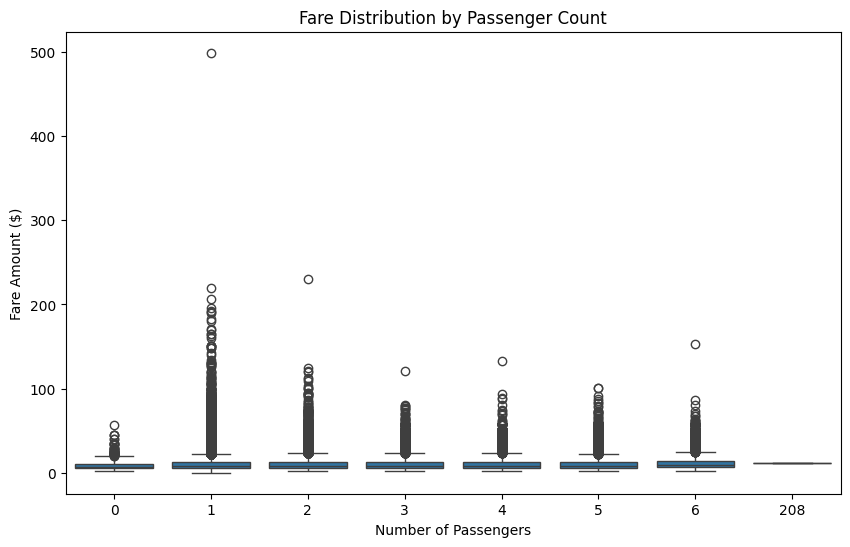

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='fare_amount', data=df)
plt.title('Fare Distribution by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount ($)')
plt.show()

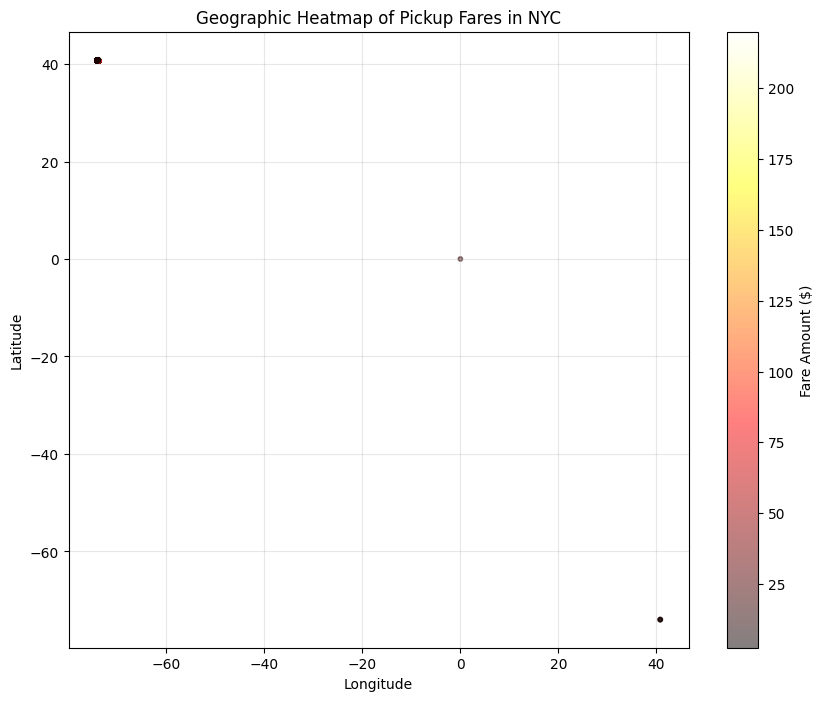

In [12]:
# We take a sample of 5000 points to keep the plot fast
sample_df = df.sample(5000)

plt.figure(figsize=(10, 8))
plt.scatter(sample_df['pickup_longitude'], sample_df['pickup_latitude'], 
            c=sample_df['fare_amount'], cmap='hot', s=10, alpha=0.5)
plt.colorbar(label='Fare Amount ($)')
plt.title('Geographic Heatmap of Pickup Fares in NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()